</div>
<div class="alert" style="background-color: #fff1f2; color: #9f1239; border-left: 6px solid #e11d48; border-top: 1px solid #fecdd3; border-right: 1px solid #fecdd3; border-bottom: 1px solid #fecdd3; border-radius: 8px; padding: 18px 22px; box-shadow: 0 4px 6px -1px rgba(225, 29, 72, 0.08); font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;" id="my-bookmark">
    <div style="font-size: 12px; font-weight: 700; letter-spacing: 0.8px; text-transform: uppercase; color: #e11d48; margin-bottom: 6px;">
        GOAL:
    </div>
    <div style="font-size: 16px; font-weight: 600; line-height: 1.5;">
        What seasonal or policy-driven variables influence spikes in health incidents?
    </div>
</div>

In [1]:
import numpy as np 
import pandas as pd 
import scipy as sp 
from scipy import stats 
import matplotlib 
import sqlite3 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import seaborn as sns 
import sklearn 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
import warnings 
import re

data = pd.read_pickle('all_clean_dfs.pkl')
globals().update(data)
all_dfs = data

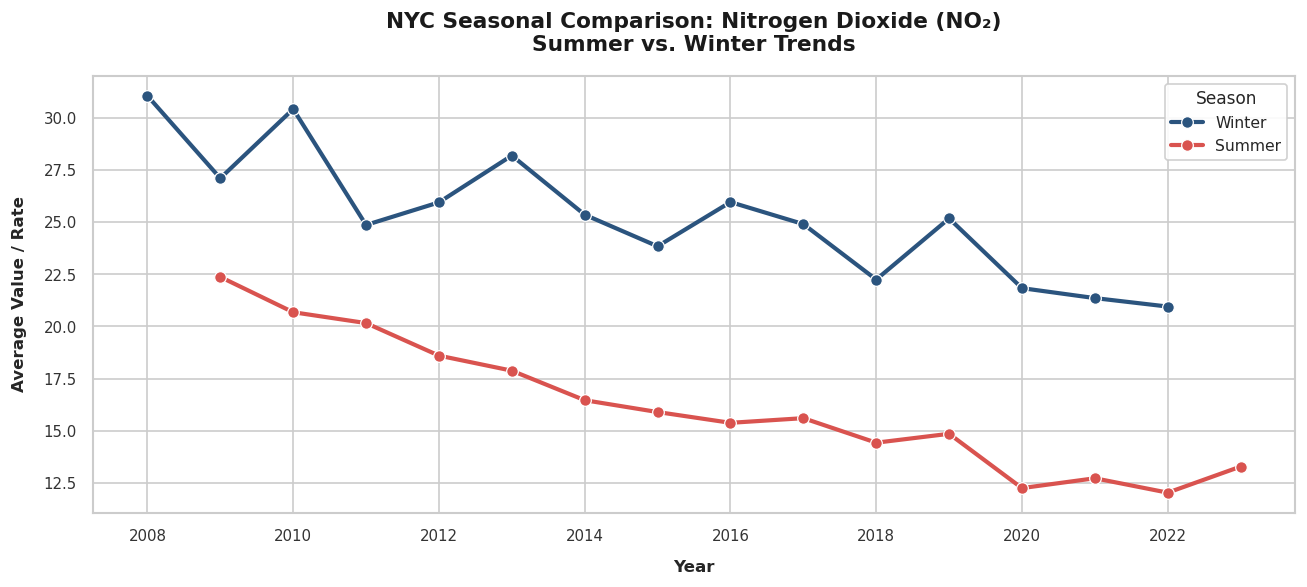

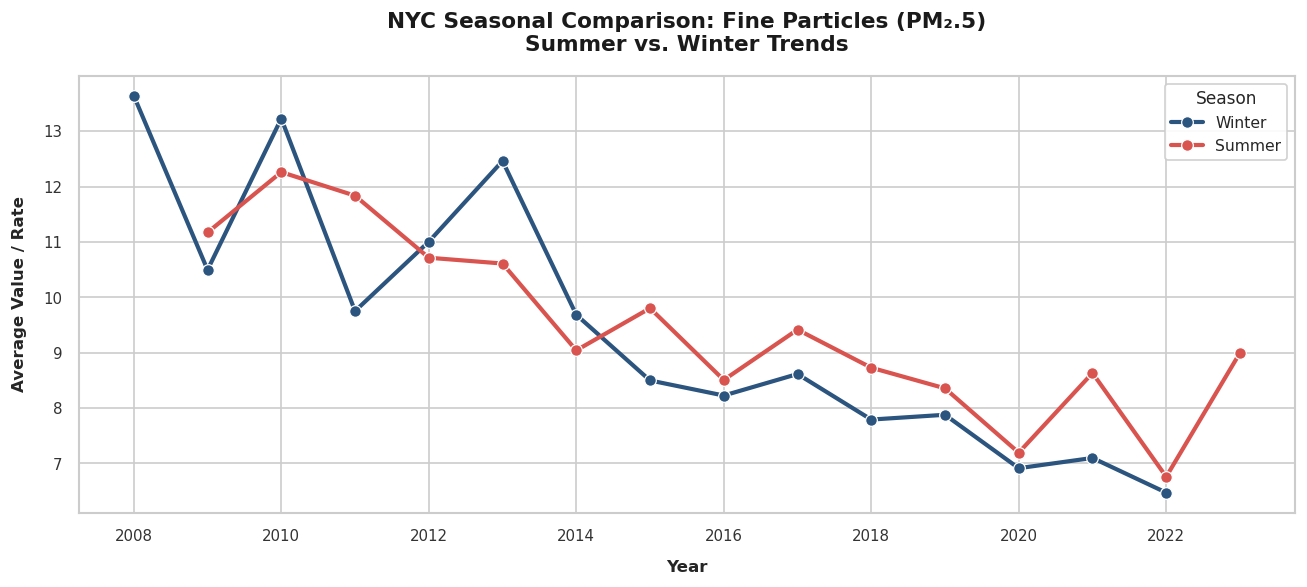

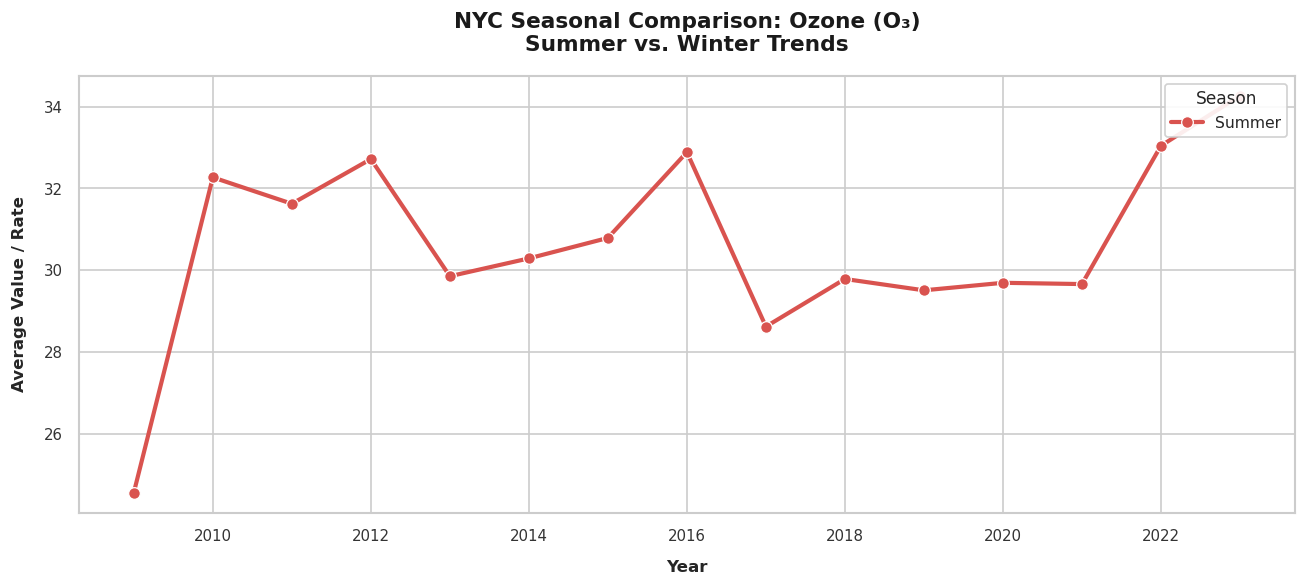

In [2]:
#winter vs summer pollutants
variables_dict = {
    "Nitrogen Dioxide (NO₂)": no2_df,
    "Fine Particles (PM₂.5)": pm25_df,
    "Ozone (O₃)": ozone_df,
    "SO₂ Emissions": so2_em_df,
    "NOₓ Emissions": nox_em_df,
    "PM₂.5 Emissions": pm25_em_df,
    "Formaldehyde": form_df,
    "Benzene": benz_df,
    "Annual VMT (Total)": vmt_df,
    "Annual VMT (Cars)": vmt_cars_df,
    "Annual VMT (Trucks)": vmt_trck_df,
    "Asthma ED Visits (PM₂.5)": asth_pm_df,
    "Asthma Hospitalizations (Ozone)": asth_oz_h_df,
    "Asthma ED Visits (Ozone)": asth_oz_ed_df,
    "Respiratory Hospitalizations (PM₂.5)": resp_df,
    "Cardiovascular Hospitalizations (PM₂.5)": cardio_df,
    "Deaths due to PM₂.5": deaths_pm_df,
    "Cardiac/Respiratory Deaths (Ozone)": deaths_oz_df,
}


def extract_season_year(val):
    val_str = str(val)
    season = (
        "Summer"
        if "summer" in val_str.lower()
        else ("Winter" if "winter" in val_str.lower() else None)
    )
    # Extract the first 4-digit year found in the string
    match = re.search(r"\d{4}", val_str)
    year = int(match.group(0)) if match else None
    return season, year


for title, df in variables_dict.items():
    if isinstance(df, pd.DataFrame) and not df.empty:
        time_col = next(
            (
                c
                for c in [
                    "Time Period",
                    "Year",
                    "Date",
                    "Season",
                    "Month",
                    "Year-Month",
                ]
                if c in df.columns
            ),
            None,
        )
        val_col = next(
            (
                c
                for c in [
                    "Data Value",
                    "Value",
                    "Estimated Annual Rate per 100,000",
                    "Mean",
                    "Amount",
                ]
                if c in df.columns
            ),
            None,
        )

        if time_col and val_col:
            # Filter for rows containing Summer or Winter
            df_filtered = df[
                df[time_col]
                .astype(str)
                .str.contains("Summer|Winter", case=False, na=False)
            ].copy()

            if df_filtered.empty:
                continue

            # Parse out seasons and years into a clean structured table
            parsed_data = []
            for _, row in df_filtered.iterrows():
                s, y = extract_season_year(row[time_col])
                if s and y:
                    parsed_data.append(
                        {"Year": y, "Season": s, "Value": row[val_col]}
                    )

            plot_df = pd.DataFrame(parsed_data)

            if not plot_df.empty:
                # Average out any potential duplicates and sort by year
                plot_df = (
                    plot_df.groupby(["Year", "Season"])["Value"]
                    .mean()
                    .reset_index()
                )
                plot_df = plot_df.sort_values("Year")

                plt.figure(figsize=(11, 5), dpi=120)
                sns.set_theme(style="whitegrid", font_scale=0.85)

                # Custom color palette: Red for Summer, Blue for Winter
                palette = {"Summer": "#D9534F", "Winter": "#2B547E"}

                ax = sns.lineplot(
                    data=plot_df,
                    x="Year",
                    y="Value",
                    hue="Season",
                    palette=palette,
                    marker="o",
                    linewidth=2.5,
                    markersize=7,
                )

                # Formatting
                plt.title(
                    f"NYC Seasonal Comparison: {title}\nSummer vs. Winter Trends",
                    fontsize=13,
                    fontweight="bold",
                    pad=15,
                    color="#1A1A1A",
                    loc="center",
                )

                plt.xlabel("Year", fontsize=10, fontweight="bold", labelpad=10)
                plt.ylabel(
                    "Average Value / Rate",
                    fontsize=10,
                    fontweight="bold",
                    labelpad=10,
                )

                # Legend configuration
                plt.legend(
                    title="Season",
                    loc="upper right",
                    frameon=True,
                    facecolor="white",
                    framealpha=0.9,
                )

                plt.xticks(fontsize=9, color="#333333")
                plt.yticks(fontsize=9, color="#333333")

                plt.tight_layout()
                plt.show()
        else:
            print(
                f"Skipped '{title}': Missing valid time column or value column."
            )

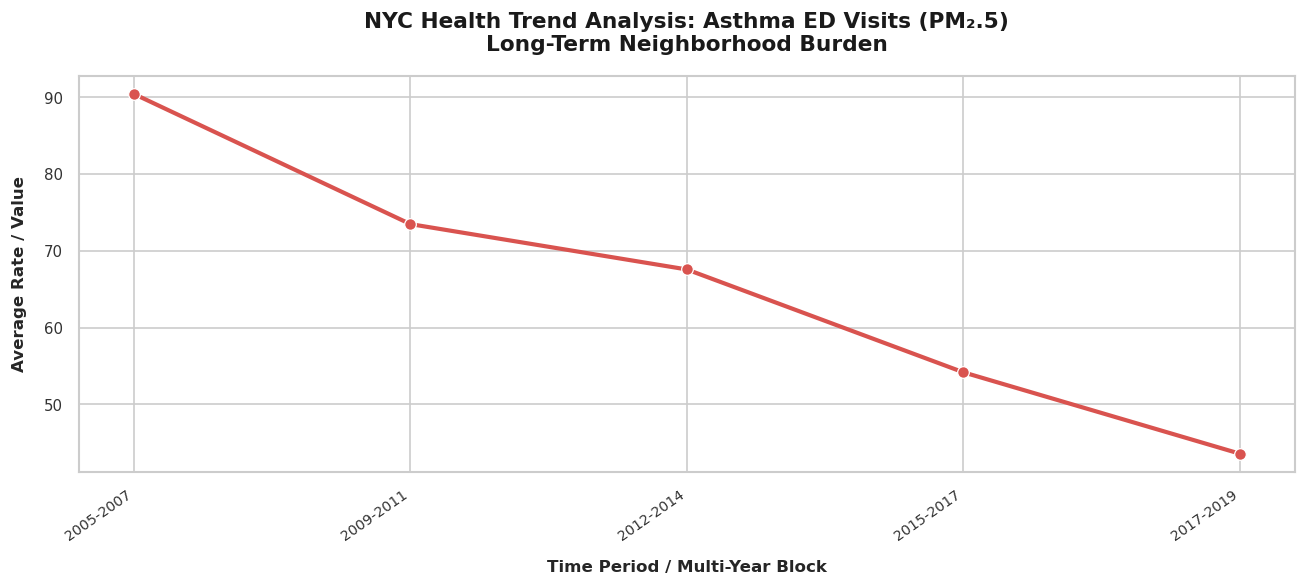

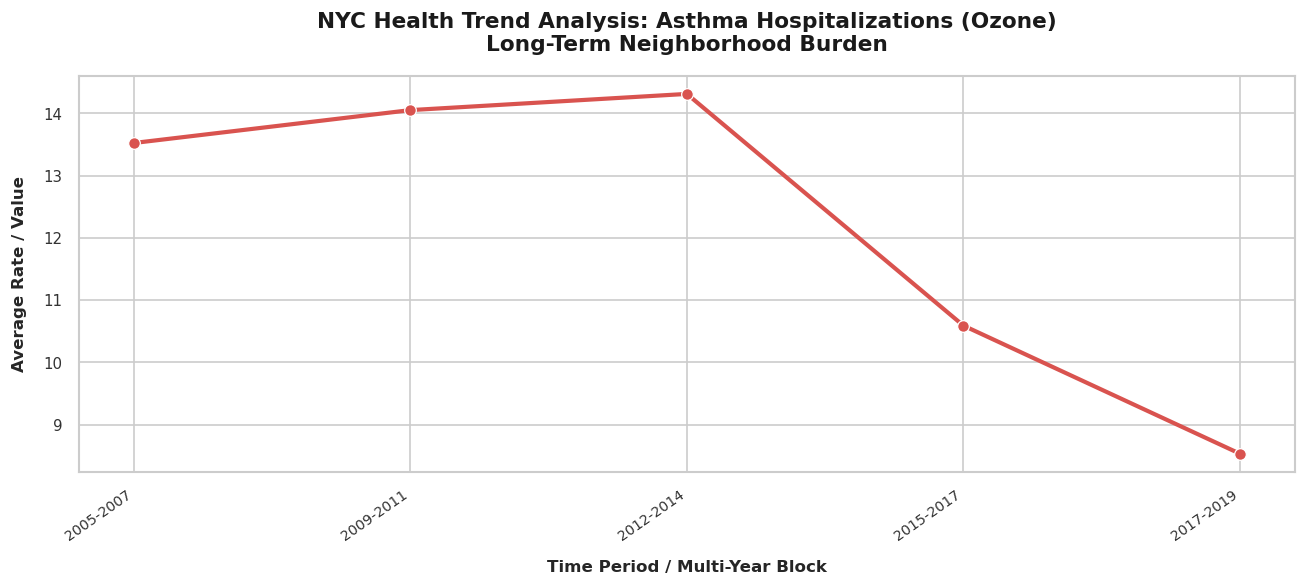

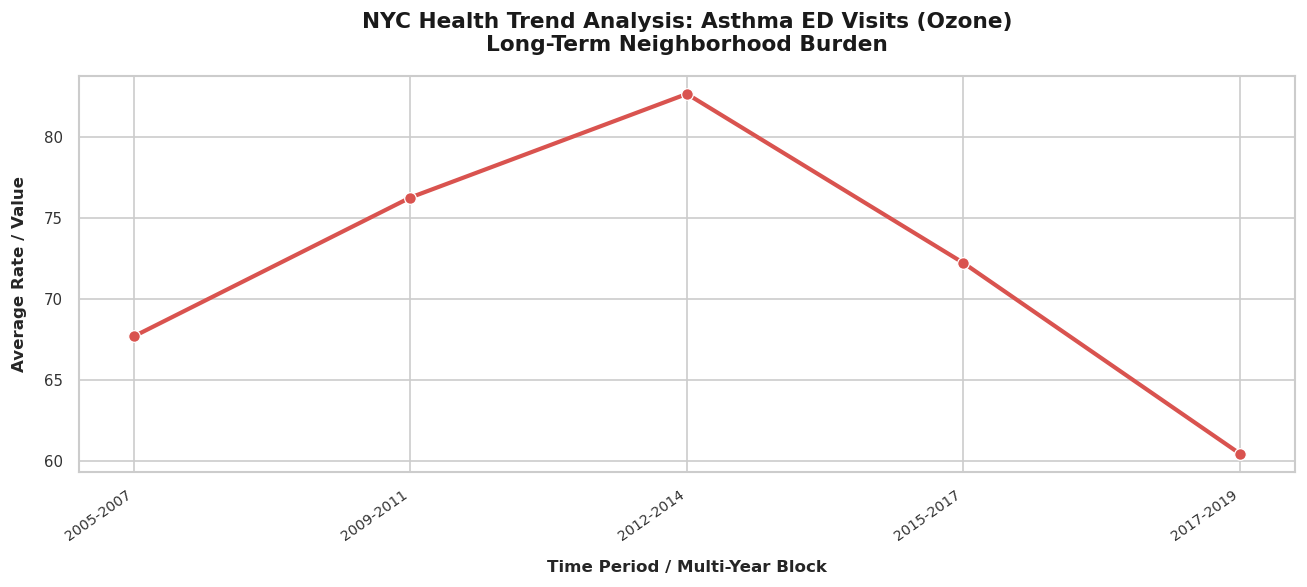

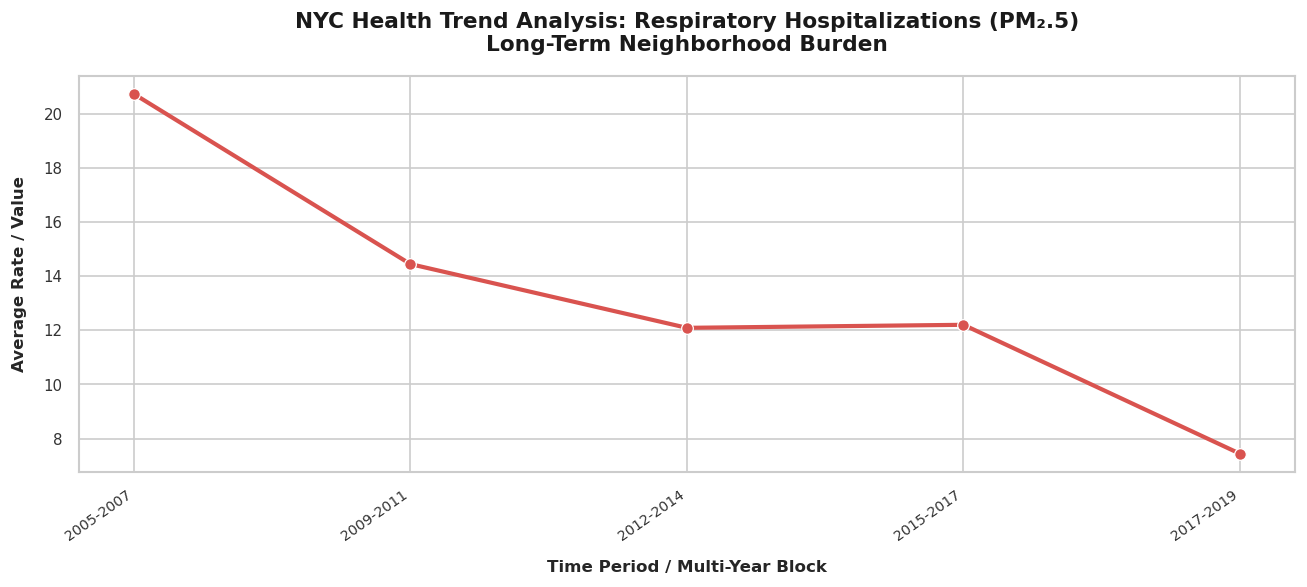

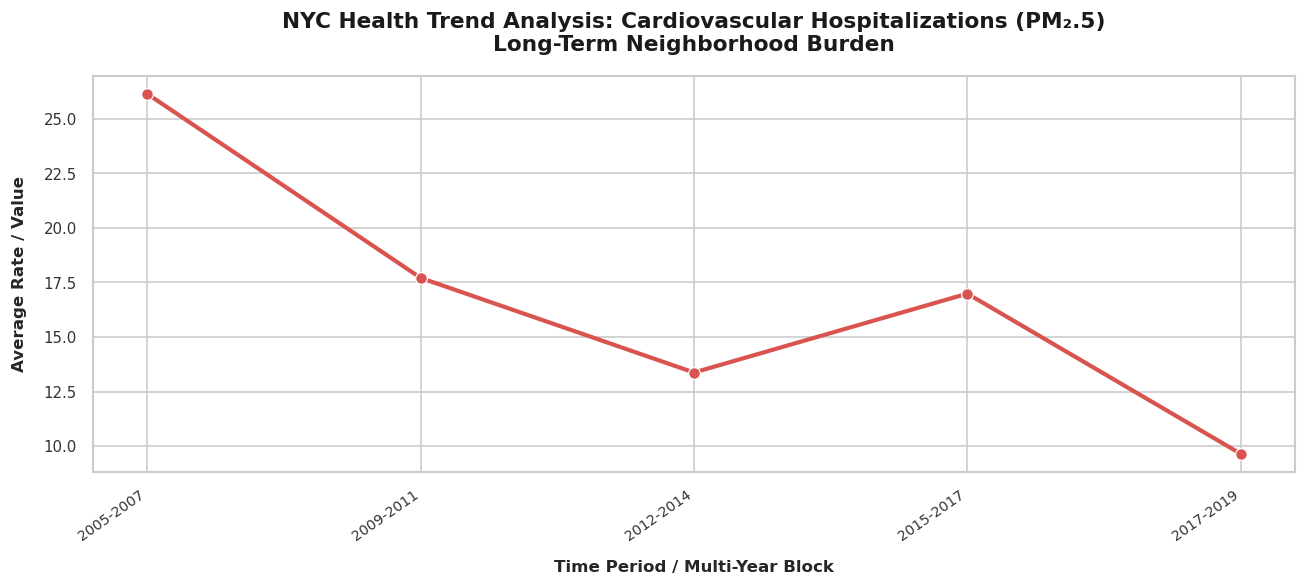

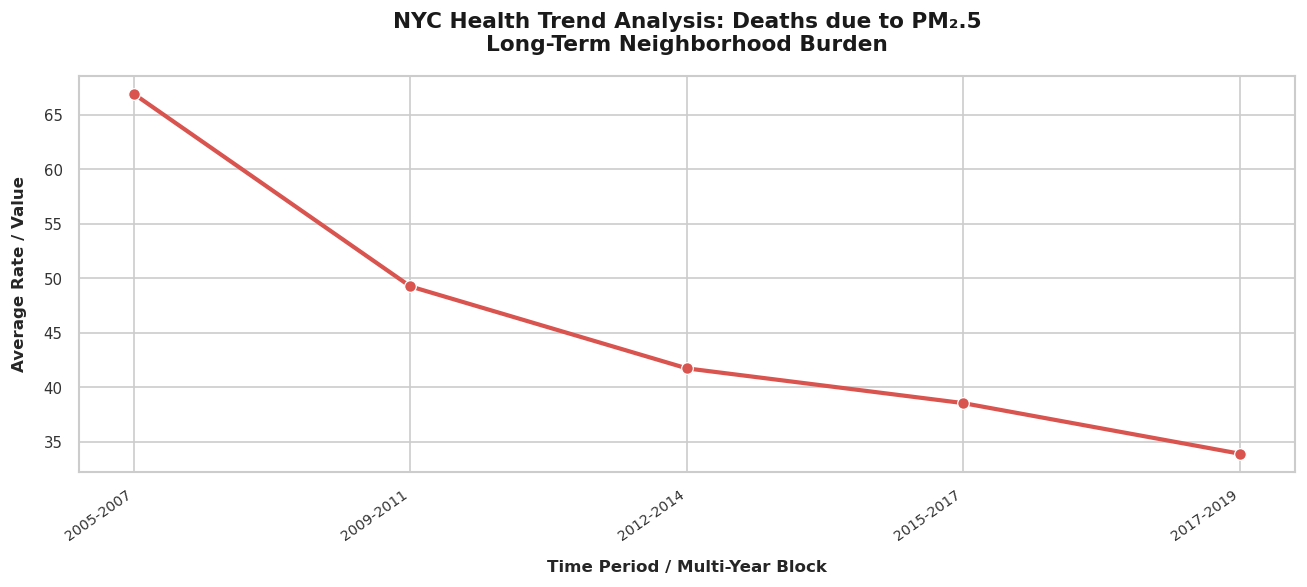

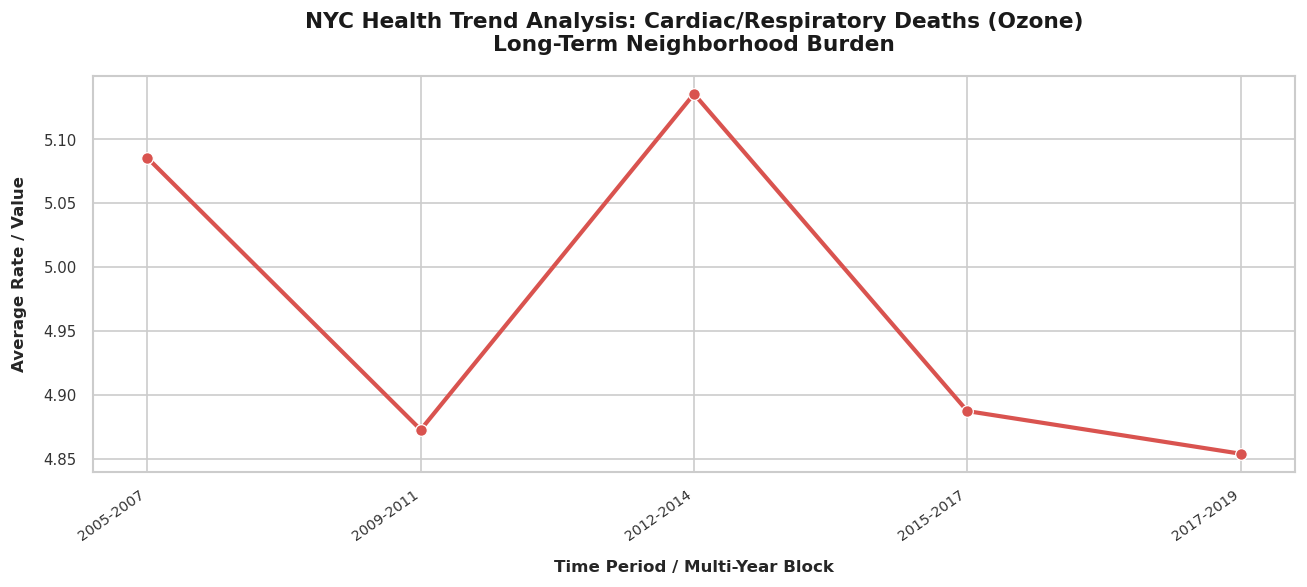

In [3]:
#winter vs summer health

# health variables
health_variables_dict = {
    "Asthma ED Visits (PM₂.5)": asth_pm_df,
    "Asthma Hospitalizations (Ozone)": asth_oz_h_df,
    "Asthma ED Visits (Ozone)": asth_oz_ed_df,
    "Respiratory Hospitalizations (PM₂.5)": resp_df,
    "Cardiovascular Hospitalizations (PM₂.5)": cardio_df,
    "Deaths due to PM₂.5": deaths_pm_df,
    "Cardiac/Respiratory Deaths (Ozone)": deaths_oz_df,
}


def extract_health_year(val):
    val_str = str(val)
    # Find all 4-digit years in the string (handles single years like '2015' or ranges like '2011-2013')
    matches = re.findall(r"\d{4}", val_str)
    if matches:
        # Return the starting year of the block as a clean integer for sorting
        return int(matches[0])
    return None


for title, df in health_variables_dict.items():
    if isinstance(df, pd.DataFrame) and not df.empty:
        time_col = next(
            (
                c
                for c in [
                    "Time Period",
                    "Year",
                    "Date",
                    "Season",
                    "Month",
                    "Year-Month",
                ]
                if c in df.columns
            ),
            None,
        )
        val_col = next(
            (
                c
                for c in [
                    "Data Value",
                    "Value",
                    "Estimated Annual Rate per 100,000",
                    "Mean",
                    "Amount",
                ]
                if c in df.columns
            ),
            None,
        )

        if time_col and val_col:
            df_filtered = df.dropna(subset=[time_col, val_col]).copy()

            if df_filtered.empty:
                continue

            # Parse out years from multi-year health blocks
            parsed_data = []
            for _, row in df_filtered.iterrows():
                y = extract_health_year(row[time_col])
                if y:
                    parsed_data.append(
                        {
                            "DisplayPeriod": str(row[time_col]),
                            "SortYear": y,
                            "Value": row[val_col],
                        }
                    )

            plot_df = pd.DataFrame(parsed_data)

            if not plot_df.empty:
                # Average out duplicates and sort chronologically by year block
                plot_df = (
                    plot_df.groupby(["DisplayPeriod", "SortYear"])["Value"]
                    .mean()
                    .reset_index()
                )
                plot_df = plot_df.sort_values("SortYear")

                plt.figure(figsize=(11, 5), dpi=120)
                sns.set_theme(style="whitegrid", font_scale=0.85)

                ax = sns.lineplot(
                    data=plot_df,
                    x="DisplayPeriod",
                    y="Value",
                    marker="o",
                    color="#D9534F",  # Distinct health-metric red tone
                    linewidth=2.5,
                    markersize=7,
                )

                # --- FIXED ORDER: Set ticks first, then labels ---
                ax.set_xticks(range(len(plot_df)))
                ax.set_xticklabels(
                    plot_df["DisplayPeriod"],
                    rotation=35,
                    ha="right",
                    fontsize=8.5,
                    color="#333333",
                )

                # Formatting
                plt.title(
                    f"NYC Health Trend Analysis: {title}\nLong-Term Neighborhood Burden",
                    fontsize=13,
                    fontweight="bold",
                    pad=15,
                    color="#1A1A1A",
                    loc="center",
                )

                plt.xlabel(
                    "Time Period / Multi-Year Block",
                    fontsize=10,
                    fontweight="bold",
                    labelpad=10,
                )
                plt.ylabel(
                    "Average Rate / Value",
                    fontsize=10,
                    fontweight="bold",
                    labelpad=10,
                )
                plt.yticks(fontsize=9, color="#333333")

                plt.tight_layout()
                plt.show()
        else:
            print(
                f"Skipped '{title}': Missing valid time column or value column."
            )

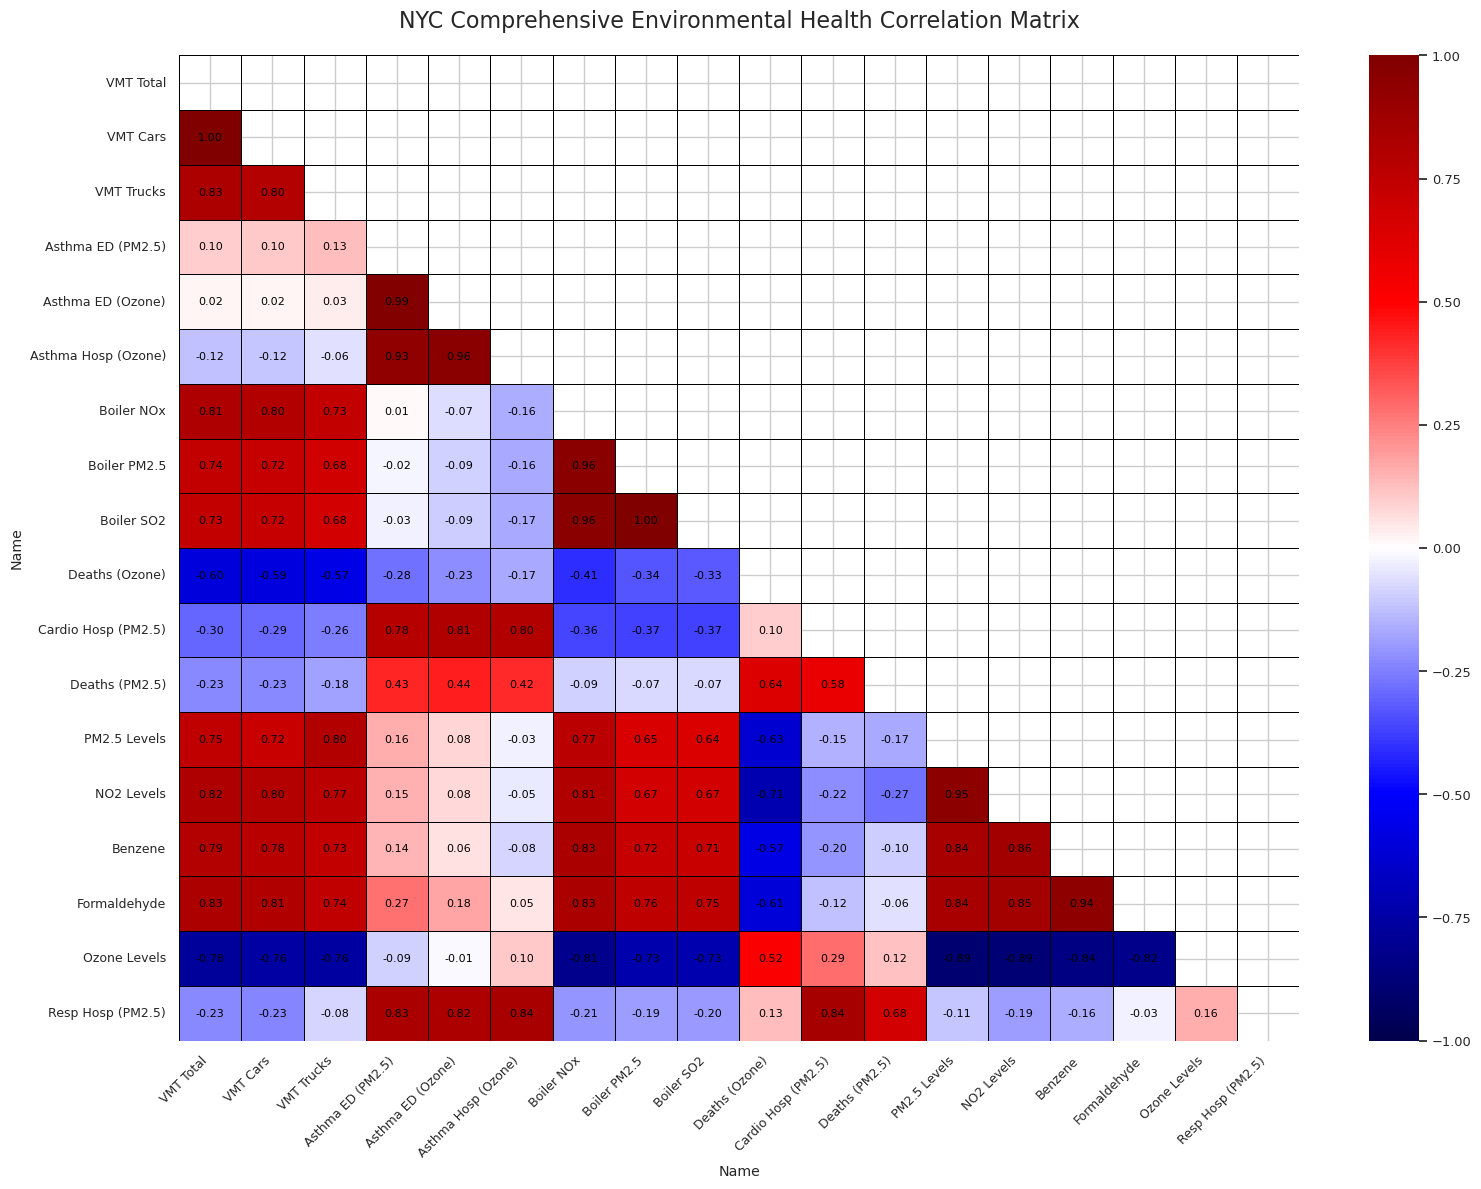

In [4]:
# heat map of envronmental & health variables

pivoted_df = clean_df.pivot_table( index="Geo Place Name", columns="Name", values="Data Value", aggfunc="mean" ) 

name_mapping = { 'Nitrogen dioxide (NO2)': 'NO2 Levels', 'Fine particles (PM 2.5)': 'PM2.5 Levels', 
                 'Boiler Emissions- Total SO2 Emissions': 'Boiler SO2', 'Ozone (O3)': 'Ozone Levels', 
                 'Asthma emergency department visits due to PM2.5': 'Asthma ED (PM2.5)', 'Annual vehicle miles traveled': 'VMT Total', 
                 'Respiratory hospitalizations due to PM2.5 (age 20+)': 'Resp Hosp (PM2.5)', 
                 'Asthma hospitalizations due to Ozone': 'Asthma Hosp (Ozone)', 'Boiler Emissions- Total NOx Emissions': 'Boiler NOx',
                 'Boiler Emissions- Total PM2.5 Emissions': 'Boiler PM2.5', 'Outdoor Air Toxics - Formaldehyde': 'Formaldehyde', 
                 'Outdoor Air Toxics - Benzene': 'Benzene', 'Asthma emergency departments visits due to Ozone': 'Asthma ED (Ozone)',
                 'Annual vehicle miles traveled (cars)': 'VMT Cars', 'Annual vehicle miles traveled (trucks)': 'VMT Trucks',
                 'Cardiovascular hospitalizations due to PM2.5 (age 40+)': 'Cardio Hosp (PM2.5)', 'Deaths due to PM2.5': 'Deaths (PM2.5)', 
                 'Cardiac and respiratory deaths due to Ozone': 'Deaths (Ozone)' } 
pivoted_df = pivoted_df.rename(columns=name_mapping) 

corr_matrix = pivoted_df.corr() 
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) 
plt.figure(figsize=(16, 12)) 
sns.heatmap( corr_matrix, mask=mask, cmap='seismic', linewidths=0.5, linecolor='black', cbar=True, vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={'size': 8, 'color': 'black'} ) 
plt.xticks(rotation=45, ha='right', fontsize=9) 
plt.yticks(rotation=0, fontsize=9) 
plt.title('NYC Comprehensive Environmental Health Correlation Matrix', size=16, pad=20) 
plt.tight_layout() 
plt.show() 

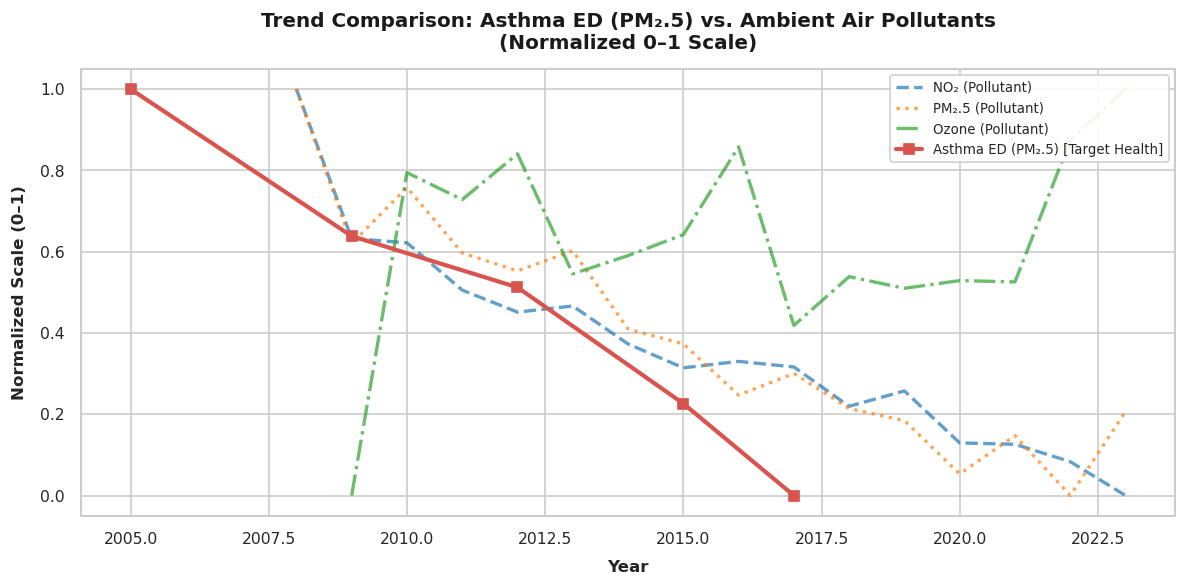

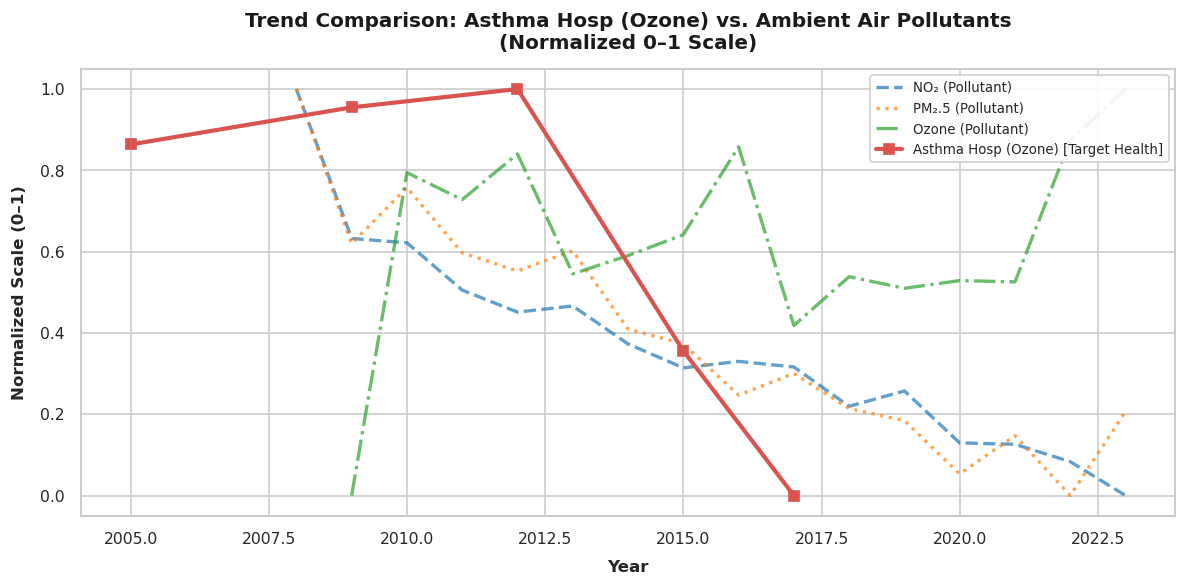

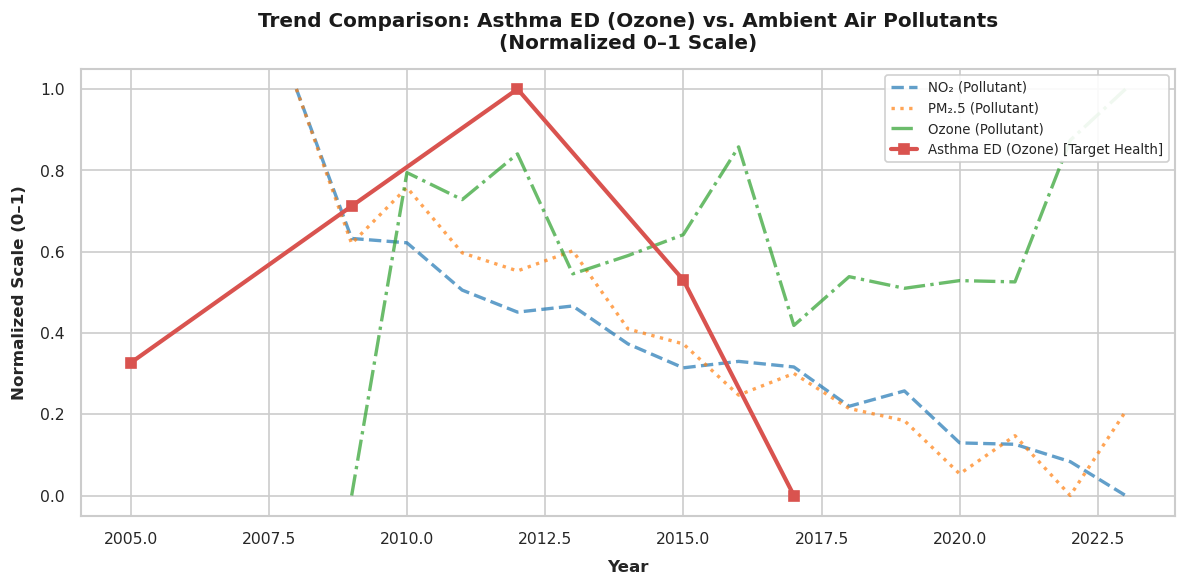

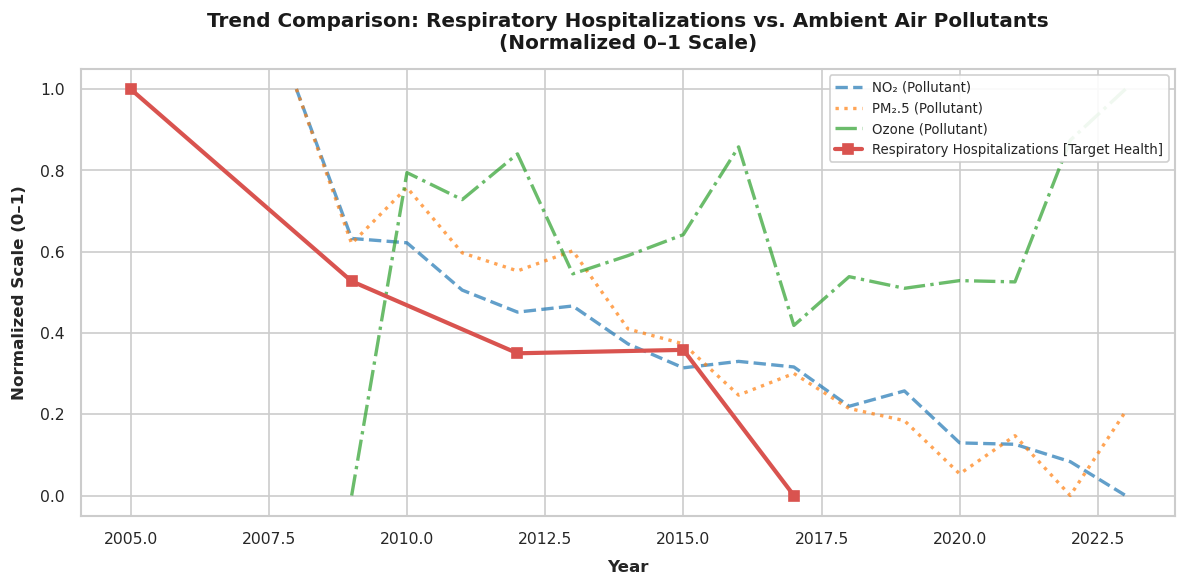

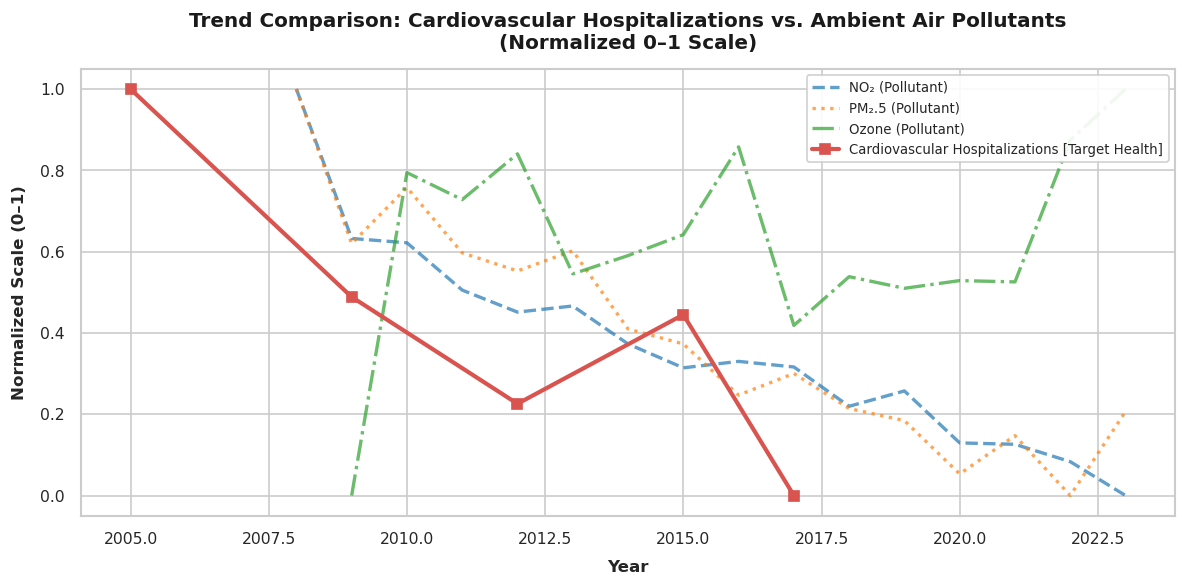

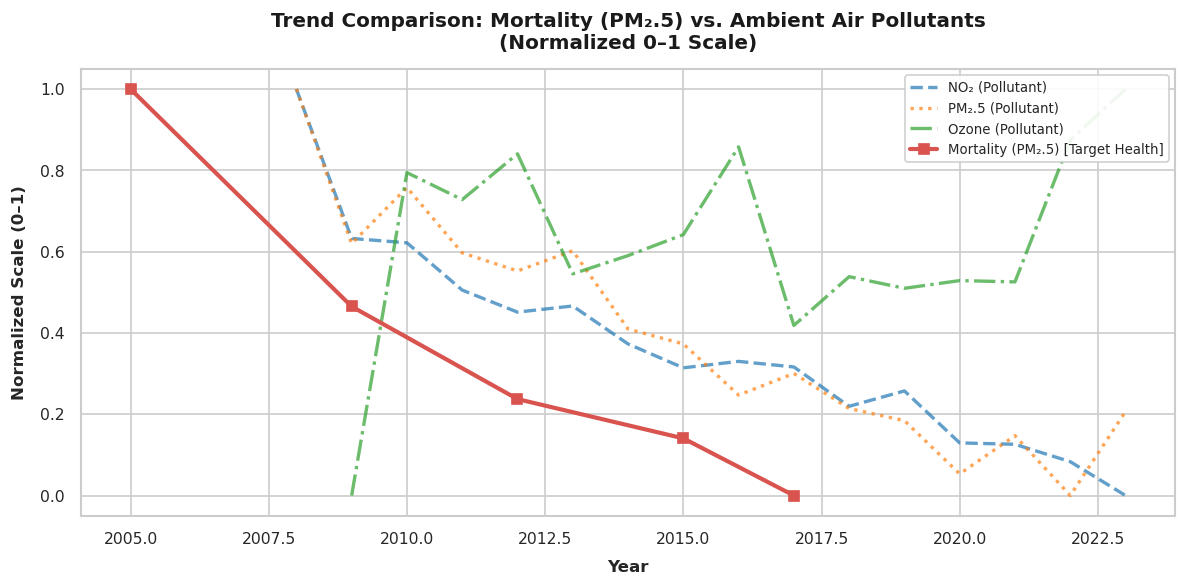

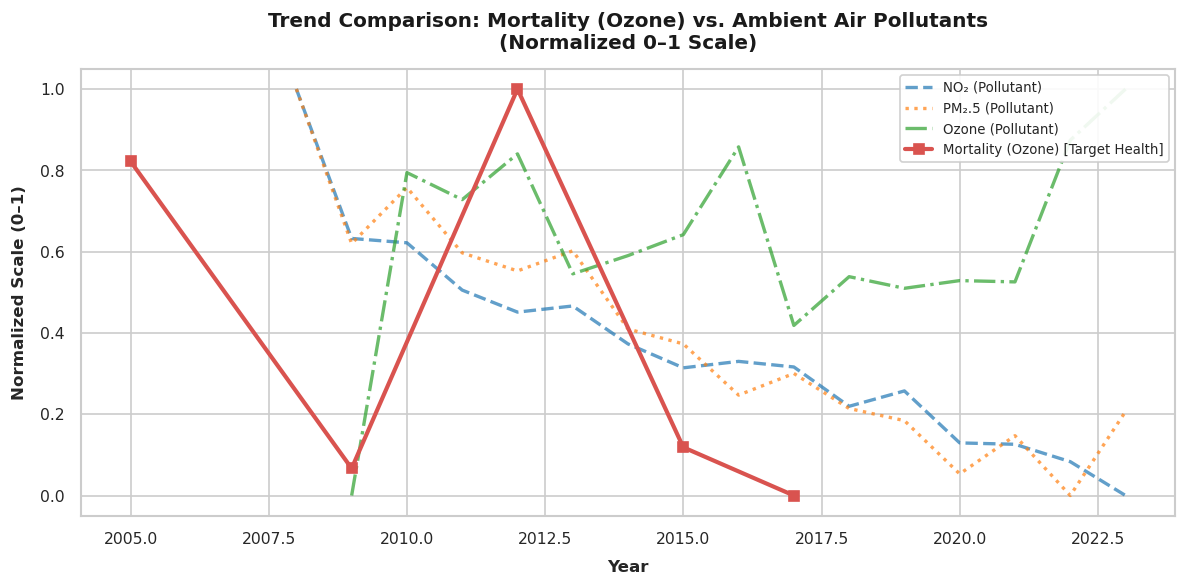

In [5]:
import re
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def extract_year(val):
  val_str = str(val)
  matches = re.findall(r"\d{4}", val_str)
  if matches:
    return int(matches[0])
  return None


# Core pollutants to compare against
pollutant_dict = {
    "NO₂ (Pollutant)": no2_df,
    "PM₂.5 (Pollutant)": pm25_df,
    "Ozone (Pollutant)": ozone_df,
}

# Distinct, high-contrast styles and colors for background pollutants
pollutant_styles = {
    "NO₂ (Pollutant)": {"color": "#1f77b4", "linestyle": "--"},  # Blue dashed
    "PM₂.5 (Pollutant)": {"color": "#ff7f0e", "linestyle": ":"},  # Orange dotted
    "Ozone (Pollutant)": (
        {"color": "#2ca02c", "linestyle": "-."}
    ),  # Green dash-dot
}

# All your health outcomes to loop through one by one
health_outcomes_dict = {
    "Asthma ED (PM₂.5)": asth_pm_df,
    "Asthma Hosp (Ozone)": asth_oz_h_df,
    "Asthma ED (Ozone)": asth_oz_ed_df,
    "Respiratory Hospitalizations": resp_df,
    "Cardiovascular Hospitalizations": cardio_df,
    "Mortality (PM₂.5)": deaths_pm_df,
    "Mortality (Ozone)": deaths_oz_df,
}

sns.set_theme(style="whitegrid", font_scale=0.85)

# Loop through each health outcome and generate its own clean, focused chart
for health_title, health_df in health_outcomes_dict.items():
  if not isinstance(health_df, pd.DataFrame) or health_df.empty:
    continue

  # Extract health time series
  h_time_col = next(
      (c for c in ["Time Period", "Year", "Date"] if c in health_df.columns), None
  )
  h_val_col = next(
      (
          c
          for c in [
              "Data Value",
              "Value",
              "Estimated Annual Rate per 100,000",
              "Mean",
          ]
          if c in health_df.columns
      ),
      None,
  )

  if not h_time_col or not h_val_col:
    continue

  h_temp = []
  for _, row in health_df.dropna(subset=[h_time_col, h_val_col]).iterrows():
    yr = extract_year(row[h_time_col])
    if yr:
      h_temp.append({"Year": yr, "Value": row[h_val_col]})

  if not h_temp:
    continue

  h_annual = (
      pd.DataFrame(h_temp)
      .groupby("Year")["Value"]
      .mean()
      .reset_index()
      .sort_values("Year")
  )

  # Normalize health data (0-1)
  h_min, h_max = h_annual["Value"].min(), h_annual["Value"].max()
  h_annual["Norm"] = (
      (h_annual["Value"] - h_min) / (h_max - h_min) if h_max > h_min else 0.5
  )

  # --- CREATE INDIVIDUAL FIGURE ---
  plt.figure(figsize=(10, 5), dpi=120)

  # 1. Plot Pollutants with high-legibility background styling
  for p_title, p_df in pollutant_dict.items():
    if isinstance(p_df, pd.DataFrame) and not p_df.empty:
      p_time = next(
          (c for c in ["Time Period", "Year", "Date"] if c in p_df.columns), None
      )
      p_val = next(
          (
              c
              for c in [
                  "Data Value",
                  "Value",
                  "Estimated Annual Rate per 100,000",
                  "Mean",
              ]
              if c in p_df.columns
          ),
          None,
      )
      if p_time and p_val:
        p_temp = []
        for _, row in p_df.dropna(subset=[p_time, p_val]).iterrows():
          yr = extract_year(row[p_time])
          if yr:
            p_temp.append({"Year": yr, "Value": row[p_val]})
        if p_temp:
          p_annual = (
              pd.DataFrame(p_temp)
              .groupby("Year")["Value"]
              .mean()
              .reset_index()
              .sort_values("Year")
          )
          p_min, p_max = p_annual["Value"].min(), p_annual["Value"].max()
          p_norm = (
              (p_annual["Value"] - p_min) / (p_max - p_min)
              if p_max > p_min
              else 0.5
          )

          style = pollutant_styles.get(
              p_title, {"color": "gray", "linestyle": "--"}
          )

          plt.plot(
              p_annual["Year"],
              p_norm,
              label=p_title,
              color=style["color"],
              linestyle=style["linestyle"],
              alpha=0.7,  # Clear visibility without washing out
              linewidth=2.0,  # Thicker body for easy tracking
          )

  # 2. Plot the Target Health Outcome as a bold, prominent solid line
  plt.plot(
      h_annual["Year"],
      h_annual["Norm"],
      label=f"{health_title} [Target Health]",
      linestyle="-",
      marker="s",
      color="#D9534F",
      linewidth=2.5,
      markersize=6,
  )

  plt.title(
      f"Trend Comparison: {health_title} vs. Ambient Air Pollutants\n(Normalized 0–1 Scale)",
      fontsize=12,
      fontweight="bold",
      pad=12,
      color="#1A1A1A",
  )
  plt.xlabel("Year", fontsize=10, fontweight="bold", labelpad=8)
  plt.ylabel("Normalized Scale (0–1)", fontsize=10, fontweight="bold", labelpad=8)

  plt.legend(
      loc="upper right",
      frameon=True,
      facecolor="white",
      framealpha=0.9,
      fontsize=8,
  )
  plt.tight_layout()
  plt.show()